# Loan Approval Modeling 

>This synthetic dataset comprises 20,000 records of personal and financial data, designed to facilitate the development of predictive models for risk assessment. It serves two primary purposes:

>> Risk Score Regression: To predict a continuous risk score associated with each individual's likelihood of loan default or financial instability.

>>Binary Classification: To determine the binary outcome of loan approval, indicating whether an applicant is likely to be approved or denied for a loan.

In [1]:
import pandas as pd
import numpy as np

#for visualizing:-
import matplotlib.pyplot as plt
import seaborn as sns

Dataset :
https://www.kaggle.com/datasets/lorenzozoppelletto/financial-risk-for-loan-approval?select=Loan.csv

In [2]:
rd=pd.read_csv("Loan.csv")
rd

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2072-09-29,44,30180,587,Employed,High School,19,24521,36,Married,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,0,55.0
19996,2072-09-30,56,49246,567,Employed,Associate,33,25818,36,Married,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,0,54.0
19997,2072-10-01,44,48958,645,Employed,Bachelor,20,37033,72,Married,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,0,45.0
19998,2072-10-02,60,41025,560,Employed,High School,36,14760,72,Married,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,0,59.0


# Step1 : **Understanding**

In [3]:
rd.shape

(20000, 36)

In [4]:
print("The Features of the datadet are:")
ftrs_list=[feature for feature in rd.columns]
for feature in ftrs_list:
    print(feature)

The Features of the datadet are:
ApplicationDate
Age
AnnualIncome
CreditScore
EmploymentStatus
EducationLevel
Experience
LoanAmount
LoanDuration
MaritalStatus
NumberOfDependents
HomeOwnershipStatus
MonthlyDebtPayments
CreditCardUtilizationRate
NumberOfOpenCreditLines
NumberOfCreditInquiries
DebtToIncomeRatio
BankruptcyHistory
LoanPurpose
PreviousLoanDefaults
PaymentHistory
LengthOfCreditHistory
SavingsAccountBalance
CheckingAccountBalance
TotalAssets
TotalLiabilities
MonthlyIncome
UtilityBillsPaymentHistory
JobTenure
NetWorth
BaseInterestRate
InterestRate
MonthlyLoanPayment
TotalDebtToIncomeRatio
LoanApproved
RiskScore


Explanation of the features in the dataset:

1. **ApplicationDate**: The date when the loan application was submitted.
2. **Age**: The age of the loan applicant.
3. **AnnualIncome**: The yearly income of the applicant, typically used to evaluate loan repayment capacity.
4. **CreditScore**: A numerical representation of the applicant’s creditworthiness based on their credit history.
5. **EmploymentStatus**: The current employment status of the applicant (e.g., employed, unemployed, self-employed).
6. **EducationLevel**: The highest level of education attained by the applicant.
7. **Experience**: The number of years the applicant has been in their current occupation or field.
8. **LoanAmount**: The amount of money the applicant is requesting as a loan.
9. **LoanDuration**: The period (in months or years) over which the loan is to be repaid.
10. **MaritalStatus**: The marital status of the applicant (e.g., single, married, divorced).
11. **NumberOfDependents**: The number of people financially dependent on the applicant (e.g., children, elderly parents).
12. **HomeOwnershipStatus**: Whether the applicant owns, rents, or has other living arrangements regarding their home.
13. **MonthlyDebtPayments**: The total amount the applicant is currently paying each month toward their existing debts.
14. **CreditCardUtilizationRate**: The percentage of available credit being used by the applicant (credit card balance divided by total credit limit).
15. **NumberOfOpenCreditLines**: The number of active credit accounts the applicant has (e.g., credit cards, loans).
16. **NumberOfCreditInquiries**: The number of times a credit inquiry has been made on the applicant’s account (usually when applying for credit).
17. **DebtToIncomeRatio**: The ratio of the applicant’s total monthly debt payments to their monthly income, used to assess their ability to take on more debt.
18. **BankruptcyHistory**: Indicates whether the applicant has filed for bankruptcy in the past.
19. **LoanPurpose**: The reason why the applicant is seeking the loan (e.g., home improvement, education, medical).
20. **PreviousLoanDefaults**: The number of times the applicant has defaulted on previous loans.
21. **PaymentHistory**: A record of the applicant’s past payments on loans and credit lines.
22. **LengthOfCreditHistory**: The number of years the applicant has had active credit accounts.
23. **SavingsAccountBalance**: The amount of money in the applicant’s savings account.
24. **CheckingAccountBalance**: The amount of money in the applicant’s checking account.
25. **TotalAssets**: The total value of assets owned by the applicant (e.g., property, vehicles, investments).
26. **TotalLiabilities**: The total amount of liabilities (debts) the applicant owes.
27. **MonthlyIncome**: The applicant’s total monthly income.
28. **UtilityBillsPaymentHistory**: A record of how well the applicant has managed paying their utility bills.
29. **JobTenure**: The length of time the applicant has held their current job.
30. **NetWorth**: The difference between the applicant’s total assets and total liabilities.
31. **BaseInterestRate**: The general interest rate set by the financial institution or the market.
32. **InterestRate**: The specific interest rate offered to the applicant for the loan.
33. **MonthlyLoanPayment**: The amount the applicant will need to pay each month to repay the loan.
34. **TotalDebtToIncomeRatio**: A more comprehensive debt-to-income ratio that includes all of the applicant’s liabilities.
35. **`LoanApproved`**: Indicates whether the loan was approved or not (usually binary: Yes/No).
36. **`RiskScore`**: A score representing the risk level of the applicant, usually derived from various financial and personal factors to help determine loan approval and interest rate.

These features help in assessing the financial health, creditworthiness, and risk profile of the loan applicant, which ultimately determines loan approval, terms, and interest rates.

In [5]:
rd.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [6]:
rd.describe(include=['O']).T

,count,unique,top,freq
ApplicationDate,20000,20000,2072-09-17,1
EmploymentStatus,20000,3,Employed,17036
EducationLevel,20000,5,Bachelor,6054
MaritalStatus,20000,4,Married,10041
HomeOwnershipStatus,20000,4,Mortgage,7939
LoanPurpose,20000,5,Home,5925


# Step2 : **Visualization**

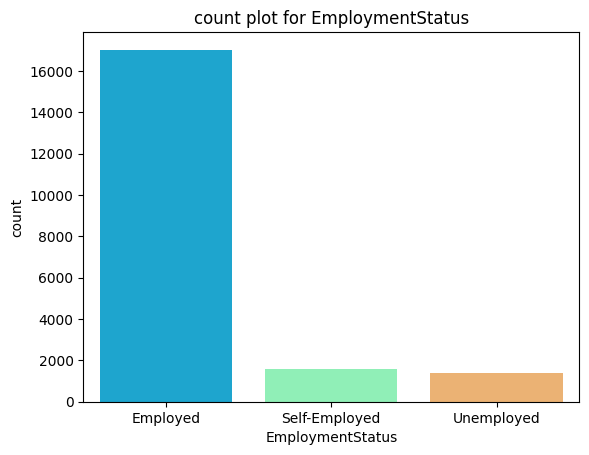

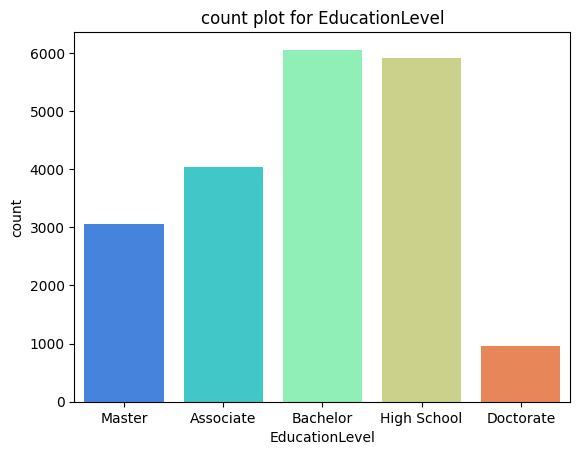

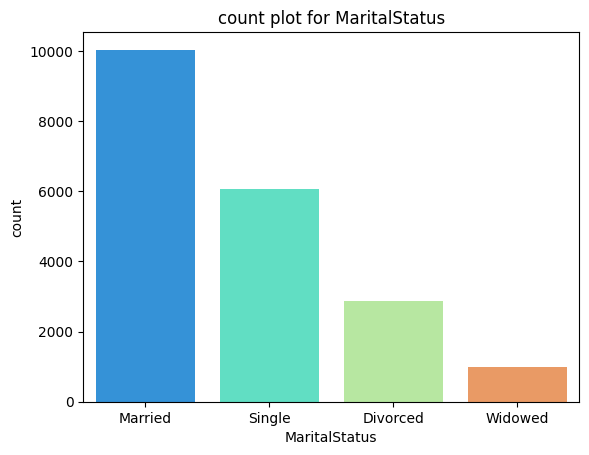

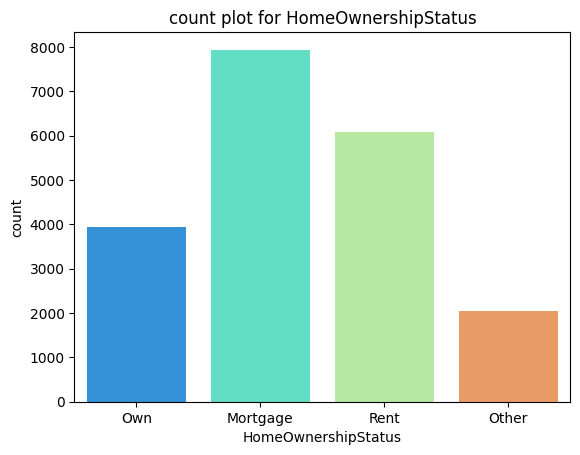

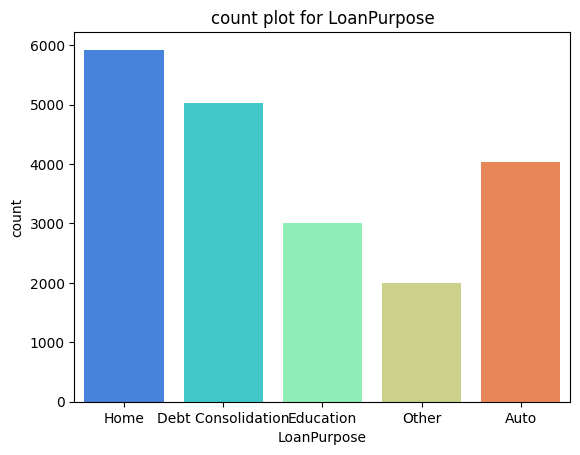

In [7]:
ctgl_clm=rd.select_dtypes(include=['object','category']).columns.tolist()

for col in ctgl_clm[1:]:    #skip the 1st feature  bcz 1st column 20000 uniq values
    plt.Figure(figsize=(6,6))
    sns.countplot(data=rd,x=col,hue=col,palette='rainbow')
    plt.title(f"count plot for {col}")
    plt.show()

**Inferences :**

Most of the loan needed persons are
* employed
* comparatively less educated
* Need loan for building home

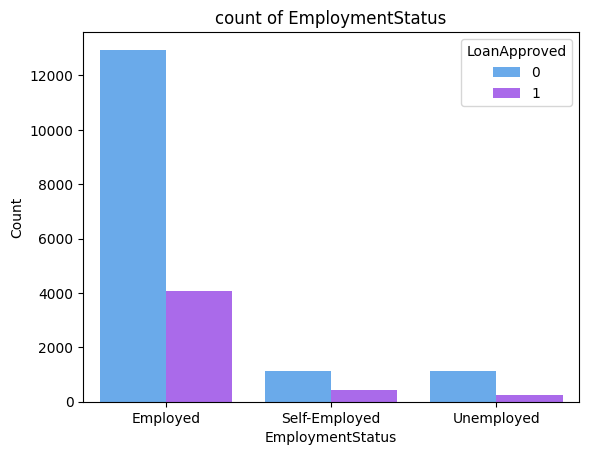

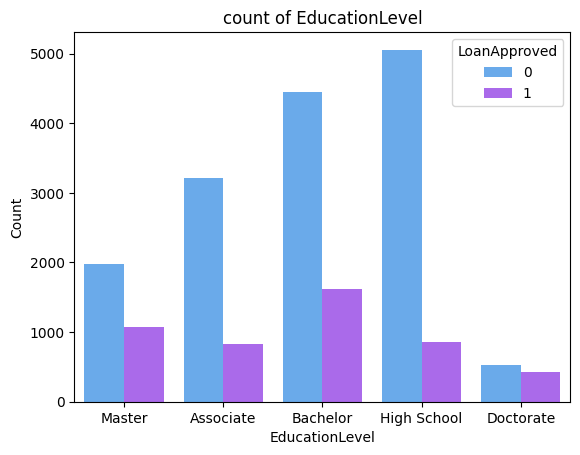

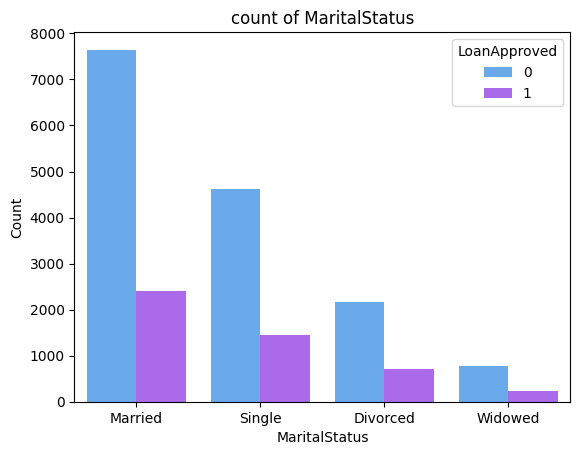

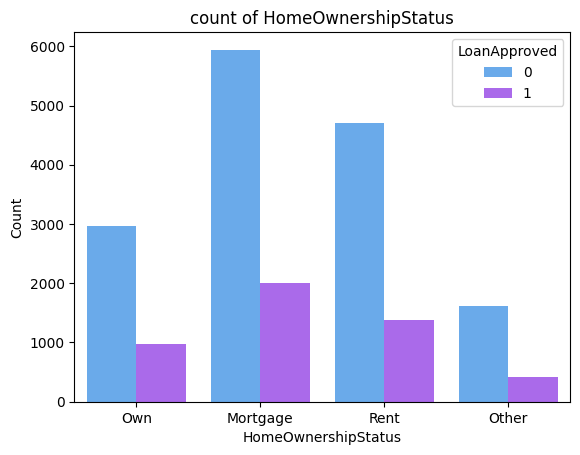

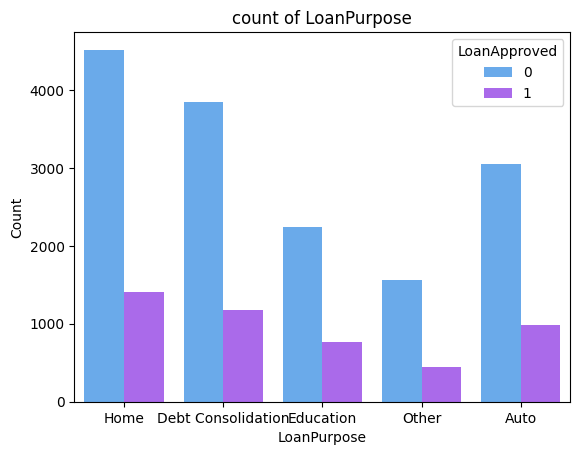

In [8]:
#plot countplots for each categorical column :
for col in ctgl_clm[1:]:    #skip the 1st feature  bcz 1st column 20000 uniq values
    plt.Figure(figsize=(8,4))
    sns.countplot(data=rd,x=col,palette='cool',hue='LoanApproved')
    plt.title(f"count of {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

**inference  :**

* Majority of loan requested are rejected in all categories(there might be some other reason affecting the riskscore)


Numerical column pairrplot

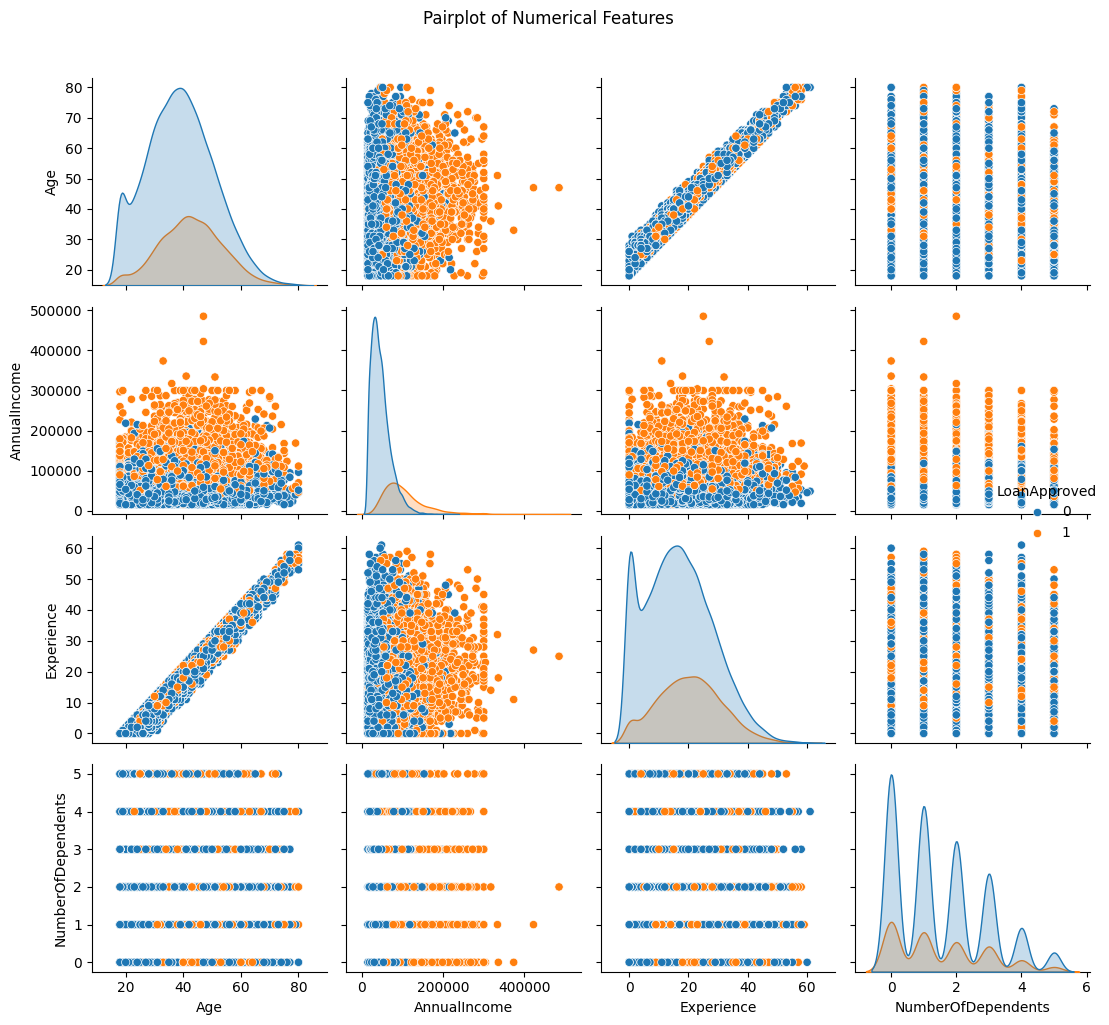

In [9]:
#Multivariate analysis :Pairplot numerical features(personal deatails)

sns.pairplot(rd[['Age','AnnualIncome','Experience','NumberOfDependents','LoanApproved']],hue='LoanApproved')
plt.suptitle('Pairplot of Numerical Features ',y=1.02)
plt.tight_layout()
plt.show()

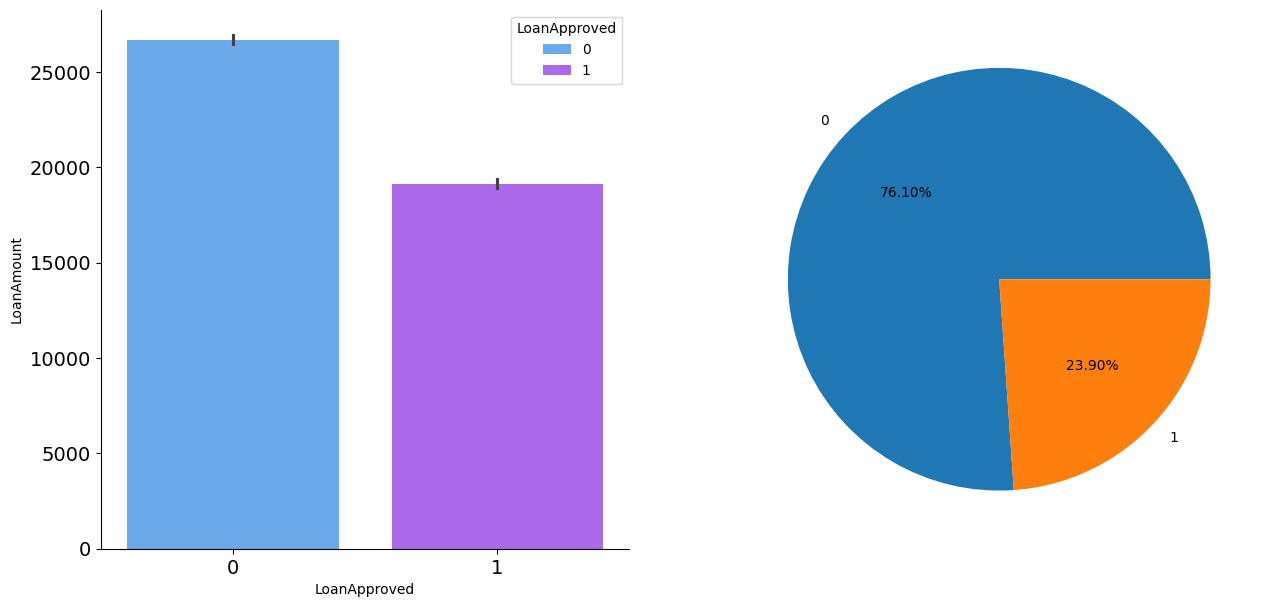

In [10]:
#checking the target 
plt.figure(figsize=(15,7))

#bairplot
ax1=plt.subplot(1,2,1)
cp=sns.barplot(x='LoanApproved',y='LoanAmount',data=rd,palette='cool',hue='LoanApproved')
ax1.set_xlabel("LoanApproved")
ax1.set_ylabel("LoanAmount")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
sns.despine(top=True,right=True)   #remove top and right side graph box line


#pieplot
ax2=plt.subplot(1,2,2)
plt.pie(x=rd['LoanApproved'].value_counts(),
        labels=list(rd['LoanApproved'].unique()),
        autopct='%2.2f%%',pctdistance=0.6)
plt.show()

# step : **Data Cleaning**

In [11]:
rd.duplicated().sum() #check duplicates in the dataset

np.int64(0)

In [12]:
rd.isnull().sum().sum() #check missing values in the dataset  (doublesum=all dataset check)

np.int64(0)

Data Transformations:-

Feature Engineering (feature creation in ML)

In [13]:
rd['BankBalance']=rd['SavingsAccountBalance']+rd['CheckingAccountBalance']

rd.drop('SavingsAccountBalance',axis=1,inplace=True)
rd.drop('CheckingAccountBalance',axis=1,inplace=True)

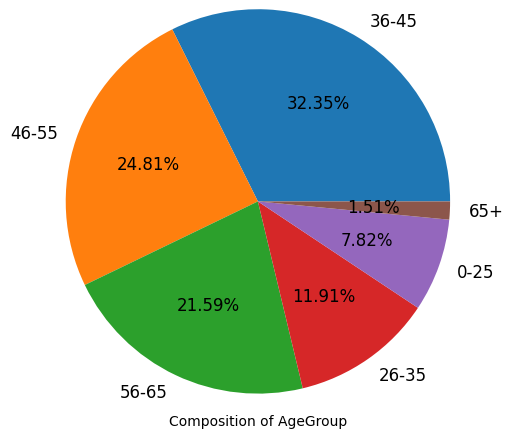

In [14]:
#age bining
rd['AgeGroup']=pd.cut(rd['Age'],bins=[0,25,35,45,55,65,100],labels=['0-25','26-35','36-45','46-55','56-65','65+'])

plt.pie(x=rd['AgeGroup'].value_counts(),labels=list(rd['AgeGroup'].unique()),autopct='%2.2f%%',radius=1.3,textprops={'fontsize':12})
plt.xlabel('Composition of AgeGroup',labelpad=20)
plt.show()

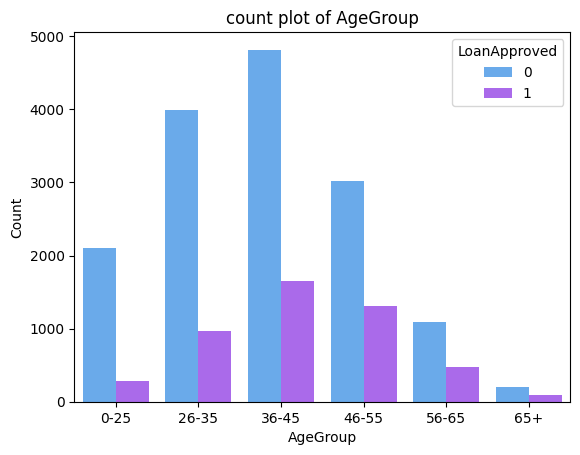

In [15]:
plt.Figure(figsize=(8,4))
sns.countplot(data=rd,x=rd['AgeGroup'],palette='cool',hue='LoanApproved')
plt.title( "count plot of AgeGroup")
plt.xlabel('AgeGroup')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [16]:
rd.drop('AgeGroup',axis=1,inplace=True)

In [17]:
rd[['year','month','day']]=rd['ApplicationDate'].str.split('-',expand=True)

rd['year']=rd['year'].astype(int)
rd['month']=rd['month'].astype(int)
rd['day']=rd['day'].astype(int)

rd[['ApplicationDate','year','month','day']]


,ApplicationDate,year,month,day
0,2018-01-01,2018,1,1
1,2018-01-02,2018,1,2
2,2018-01-03,2018,1,3
3,2018-01-04,2018,1,4
4,2018-01-05,2018,1,5
...,...,...,...,...
19995,2072-09-29,2072,9,29
19996,2072-09-30,2072,9,30
19997,2072-10-01,2072,10,1
19998,2072-10-02,2072,10,2


In [18]:
rd['year'].max()

np.int64(2072)

In [19]:
#so this column contains wrong informations
#the applicationDate feature have errors
rd.drop(['ApplicationDate','year','month','day'],axis=1,inplace=True)

(2.3)Encoding

In [20]:
ctgrl_clm=rd.select_dtypes(include=['object','category']).columns.tolist()

print("Categorical Columns :",ctgrl_clm)

Categorical Columns : ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


**ORDINAL DATA**

Many machine learning models, like decision trees and regression models, rely on the relative order of numeric values by manually assigning meaningfull, the model can better capture the relationship between the ordinal categories.

In [21]:
rd['EmploymentStatus'].unique()

array(['Employed', 'Self-Employed', 'Unemployed'], dtype=object)

In [22]:
rd['EmploymentStatus'].nunique()  #number of unique values

3

In [23]:
rd['EducationLevel'].unique()

array(['Master', 'Associate', 'Bachelor', 'High School', 'Doctorate'],
      dtype=object)

In [24]:
rd['MaritalStatus'].unique()

array(['Married', 'Single', 'Divorced', 'Widowed'], dtype=object)

In [25]:
rd['HomeOwnershipStatus'].unique()

array(['Own', 'Mortgage', 'Rent', 'Other'], dtype=object)

In [26]:
rd['LoanPurpose'].unique()

array(['Home', 'Debt Consolidation', 'Education', 'Other', 'Auto'],
      dtype=object)

In [27]:
rd['EmploymentSatatus']=rd['EmploymentStatus'].map({'Unemployed':0,'Self-Employed':1,'Employed':2})


rd['EducationLevel']=rd['EducationLevel'].map({'High School':0,'Associate':1,'Bachelor':2,'Master':3,'Doctorate':4})

In [28]:
rd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  int64  
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              20000 non-null  int64  
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

LABEL ENCODING

In [29]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

order=["Widowed","Divorced","Single","Married"]
ordinal=OrdinalEncoder(categories=[order])
rd['MaritalStatus']=ordinal.fit_transform(rd[['MaritalStatus']])
rd['MaritalStatus'].value_counts()

MaritalStatus
3.0    10041
2.0     6078
1.0     2882
0.0      999
Name: count, dtype: int64

NOMINAL DATA

In [30]:
le=LabelEncoder()

for cols in rd.select_dtypes('object').columns:
    rd[cols]=le.fit_transform(rd[cols])

In [31]:
rd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  int64  
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  int64  
 4   EducationLevel              20000 non-null  int64  
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               20000 non-null  float64
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  int64  
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

# Step3 : **Data Transforming**

# (3.1) Skewed Data

HISTOGRAM

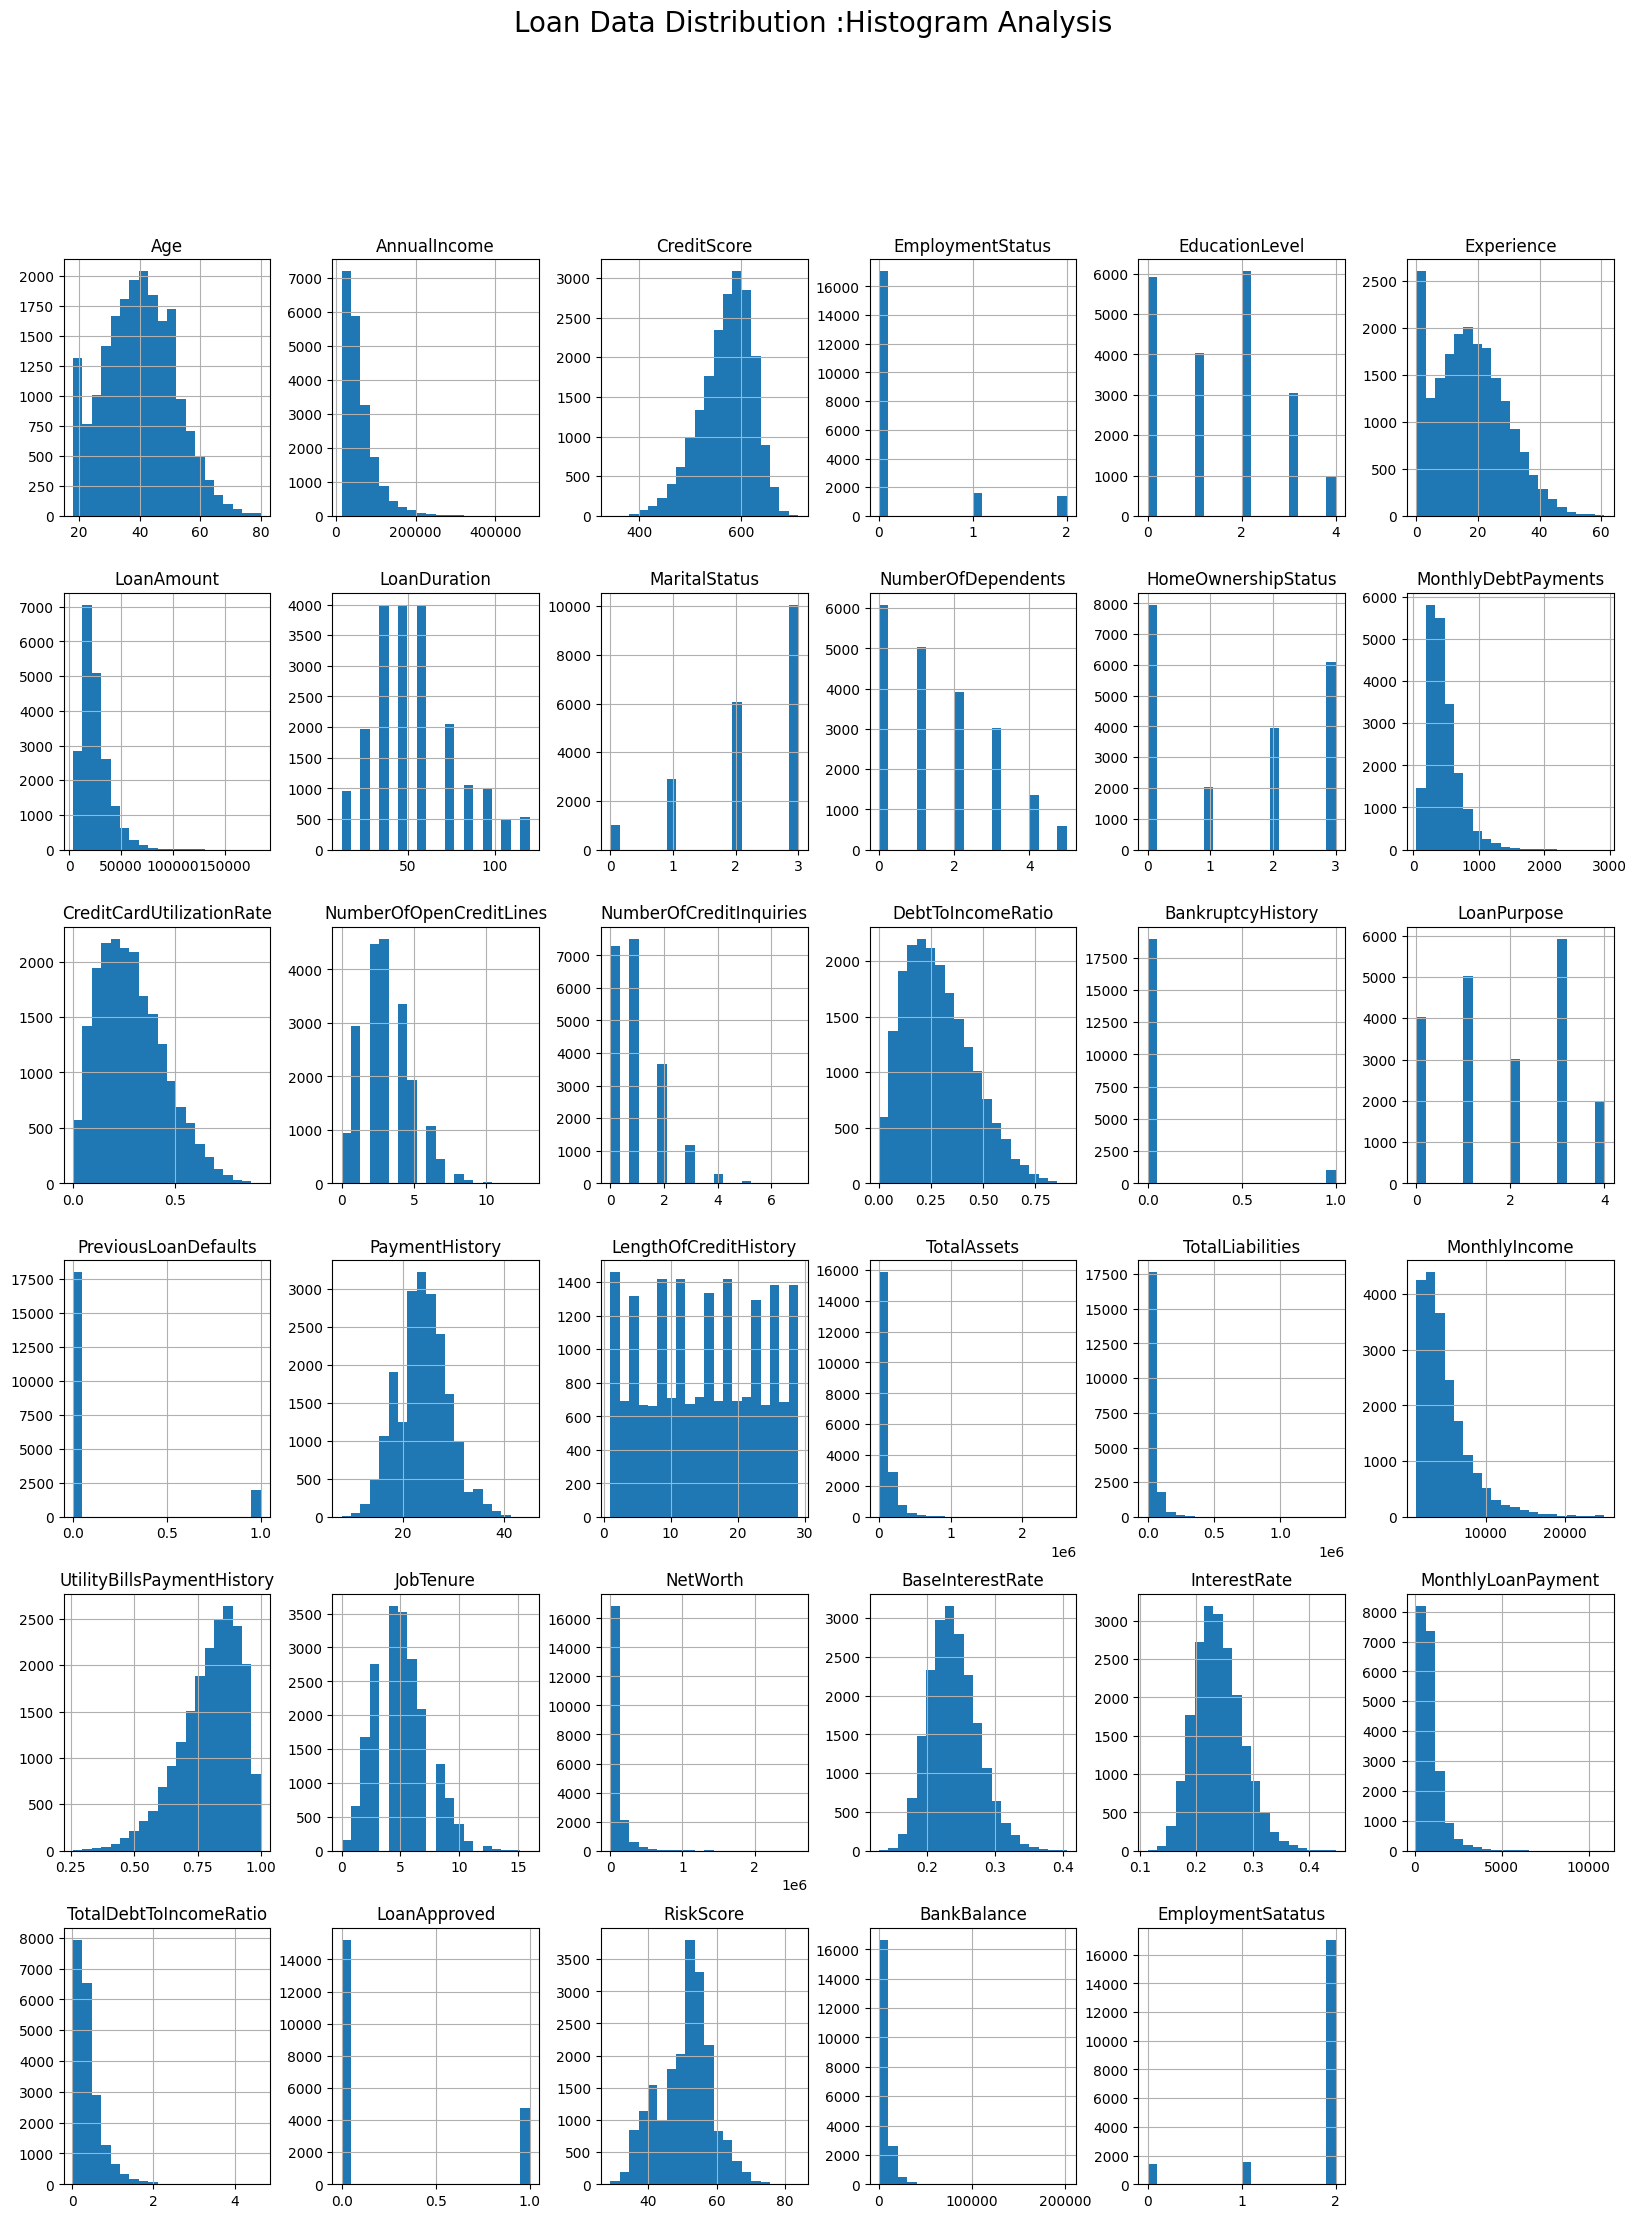

In [32]:
rd.hist(bins=20, figsize=(20,25))
plt.suptitle("Loan Data Distribution :Histogram Analysis",fontsize=20)
plt.show()

In [33]:
#calculate  skewness for each column
skewness=rd.skew()

#sort the skewness values in ascending order
sort_skew=skewness.sort_values(ascending=True)

#Display the sorted skewness values 
print(sort_skew)

EmploymentSatatus            -2.455244
MaritalStatus                -0.962494
UtilityBillsPaymentHistory   -0.846234
CreditScore                  -0.596727
RiskScore                    -0.162062
LengthOfCreditHistory         0.002989
LoanPurpose                   0.025237
HomeOwnershipStatus           0.071497
Age                           0.185964
PaymentHistory                0.213465
EducationLevel                0.273155
Experience                    0.339981
JobTenure                     0.436452
BaseInterestRate              0.461850
InterestRate                  0.485491
DebtToIncomeRatio             0.593858
NumberOfOpenCreditLines       0.599662
CreditCardUtilizationRate     0.601131
NumberOfDependents            0.639919
LoanDuration                  0.651330
NumberOfCreditInquiries       1.012065
LoanApproved                  1.224086
MonthlyDebtPayments           1.653435
LoanAmount                    1.833688
MonthlyIncome                 1.992929
AnnualIncome             

In [34]:
#LOG transformation of skewed columns 
rd['AnnualIncome']=np.log1p(rd['AnnualIncome'])
rd['LoanAmount']=np.log1p(rd['LoanAmount'])

# The log1p function in numpy stands for log(1+x),where "1p" refers to adding 1 to the input value before taking the logorithm

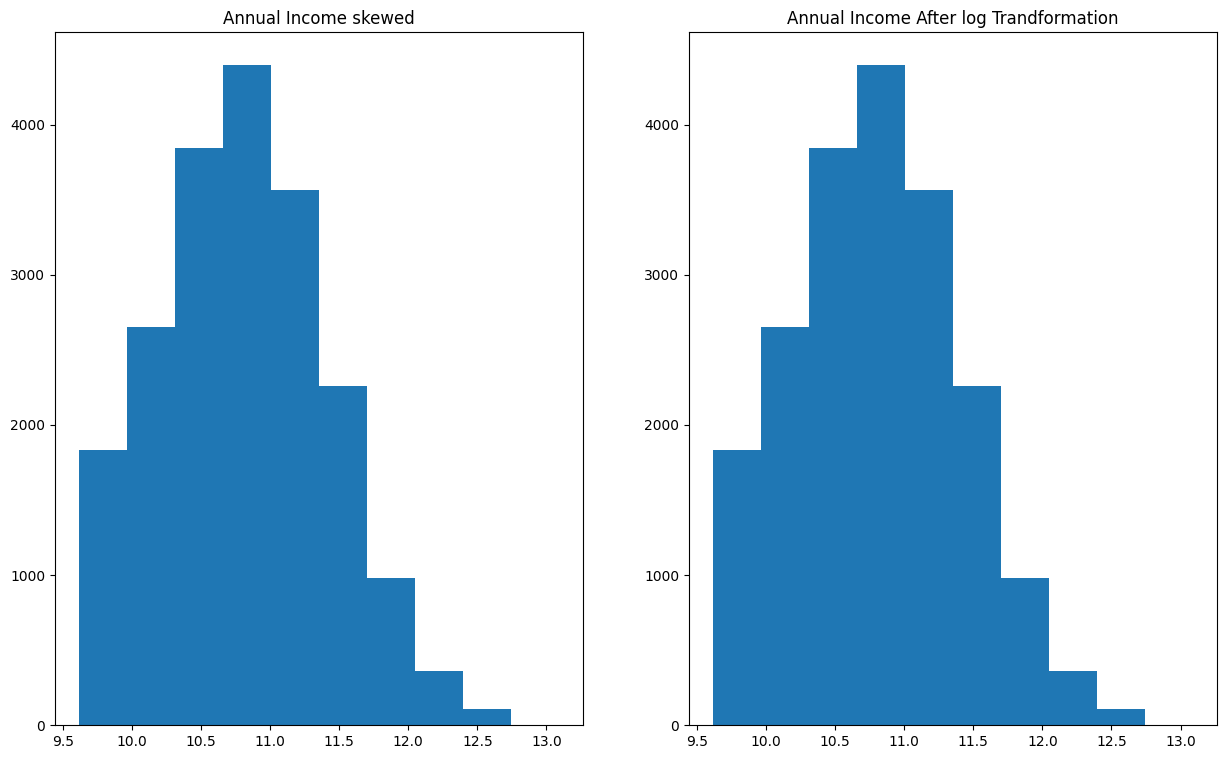

In [35]:
plt.figure(figsize=(15,9))

ax1=plt.subplot(1,2,1)
cp=plt.hist(rd['AnnualIncome'])
plt.title("Annual Income skewed")

ax2=plt.subplot(1,2,2)
plt.hist(rd['AnnualIncome'])
plt.title('Annual Income After log Trandformation')

plt.show()

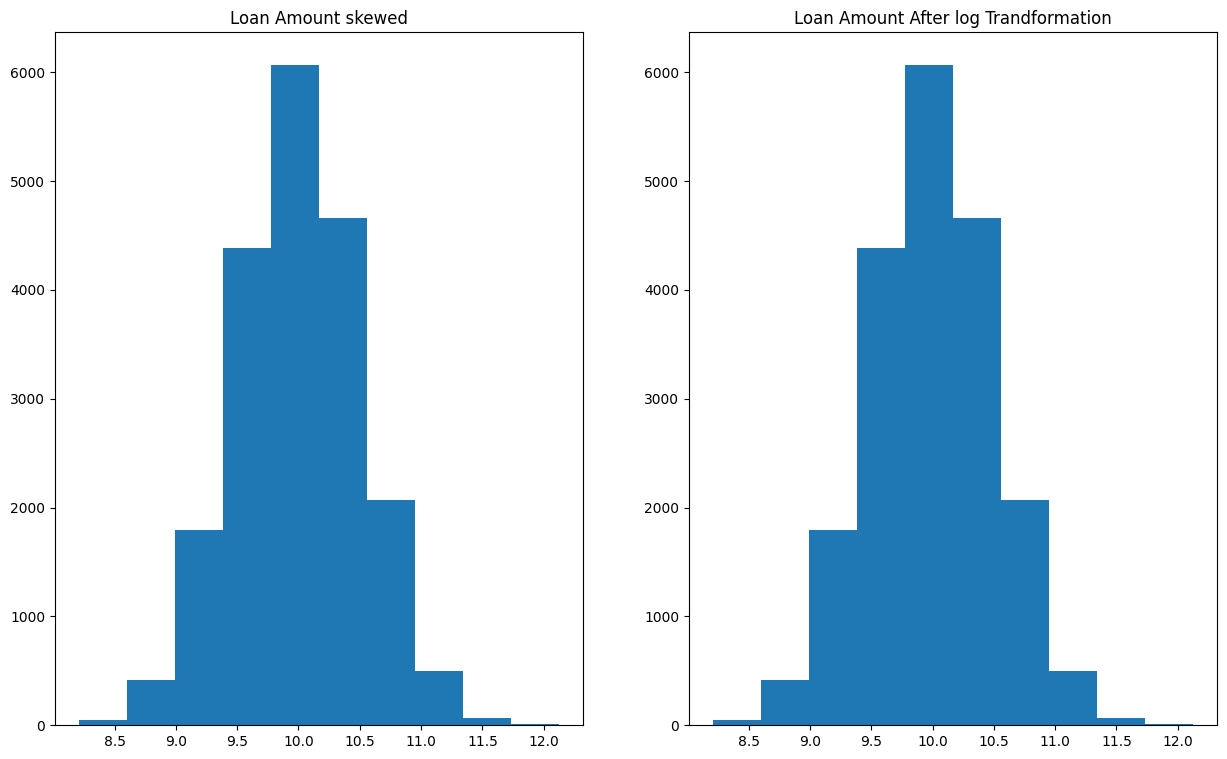

In [36]:
plt.figure(figsize=(15,9))

ax1=plt.subplot(1,2,1)
cp=plt.hist(rd['LoanAmount'])
plt.title("Loan Amount skewed")

ax2=plt.subplot(1,2,2)
plt.hist(rd['LoanAmount'])
plt.title('Loan Amount After log Trandformation')

plt.show()

In [37]:
#step1 :select numeric columns excluding "loanapproved"
numeric_cols=rd.drop(columns=['LoanApproved']).select_dtypes(include=['number'])

#step2 :calculate skewness for numeric columns
skewness=numeric_cols.skew()

#step3 :identify columns with high skewness 
highly_skewed_cols=skewness[abs(skewness)>1].index

# step4 :Apply log transformation using np.log1p() for columns with high skew
for col in highly_skewed_cols:
    rd[col]=np.log1p(rd[col])     #create a new column with log transformed values 
rd.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,BankBalance,EmploymentSatatus
0,45,10.595359,617,0.0,3,22,9.484405,48,3.0,2,...,11,11.751383,0.199652,0.227590,6.042172,0.166427,0,49.0,9.086476,1.098612
1,38,10.589358,628,0.0,1,15,10.167619,48,2.0,1,...,3,10.683042,0.207045,0.201077,6.678410,0.329198,0,52.0,8.998137,1.098612
2,47,10.614597,570,0.0,2,26,9.777244,36,3.0,2,...,6,8.557567,0.217627,0.212548,6.503400,0.379913,0,52.0,7.485492,1.098612
3,58,11.143093,545,0.0,0,34,10.542680,96,2.0,1,...,5,11.507440,0.300398,0.300911,6.955123,0.272389,0,54.0,7.970049,1.098612
4,37,11.545054,594,0.0,1,17,9.125327,36,3.0,1,...,5,12.332793,0.197184,0.175990,5.802659,0.067855,1,36.0,8.785234,1.098612


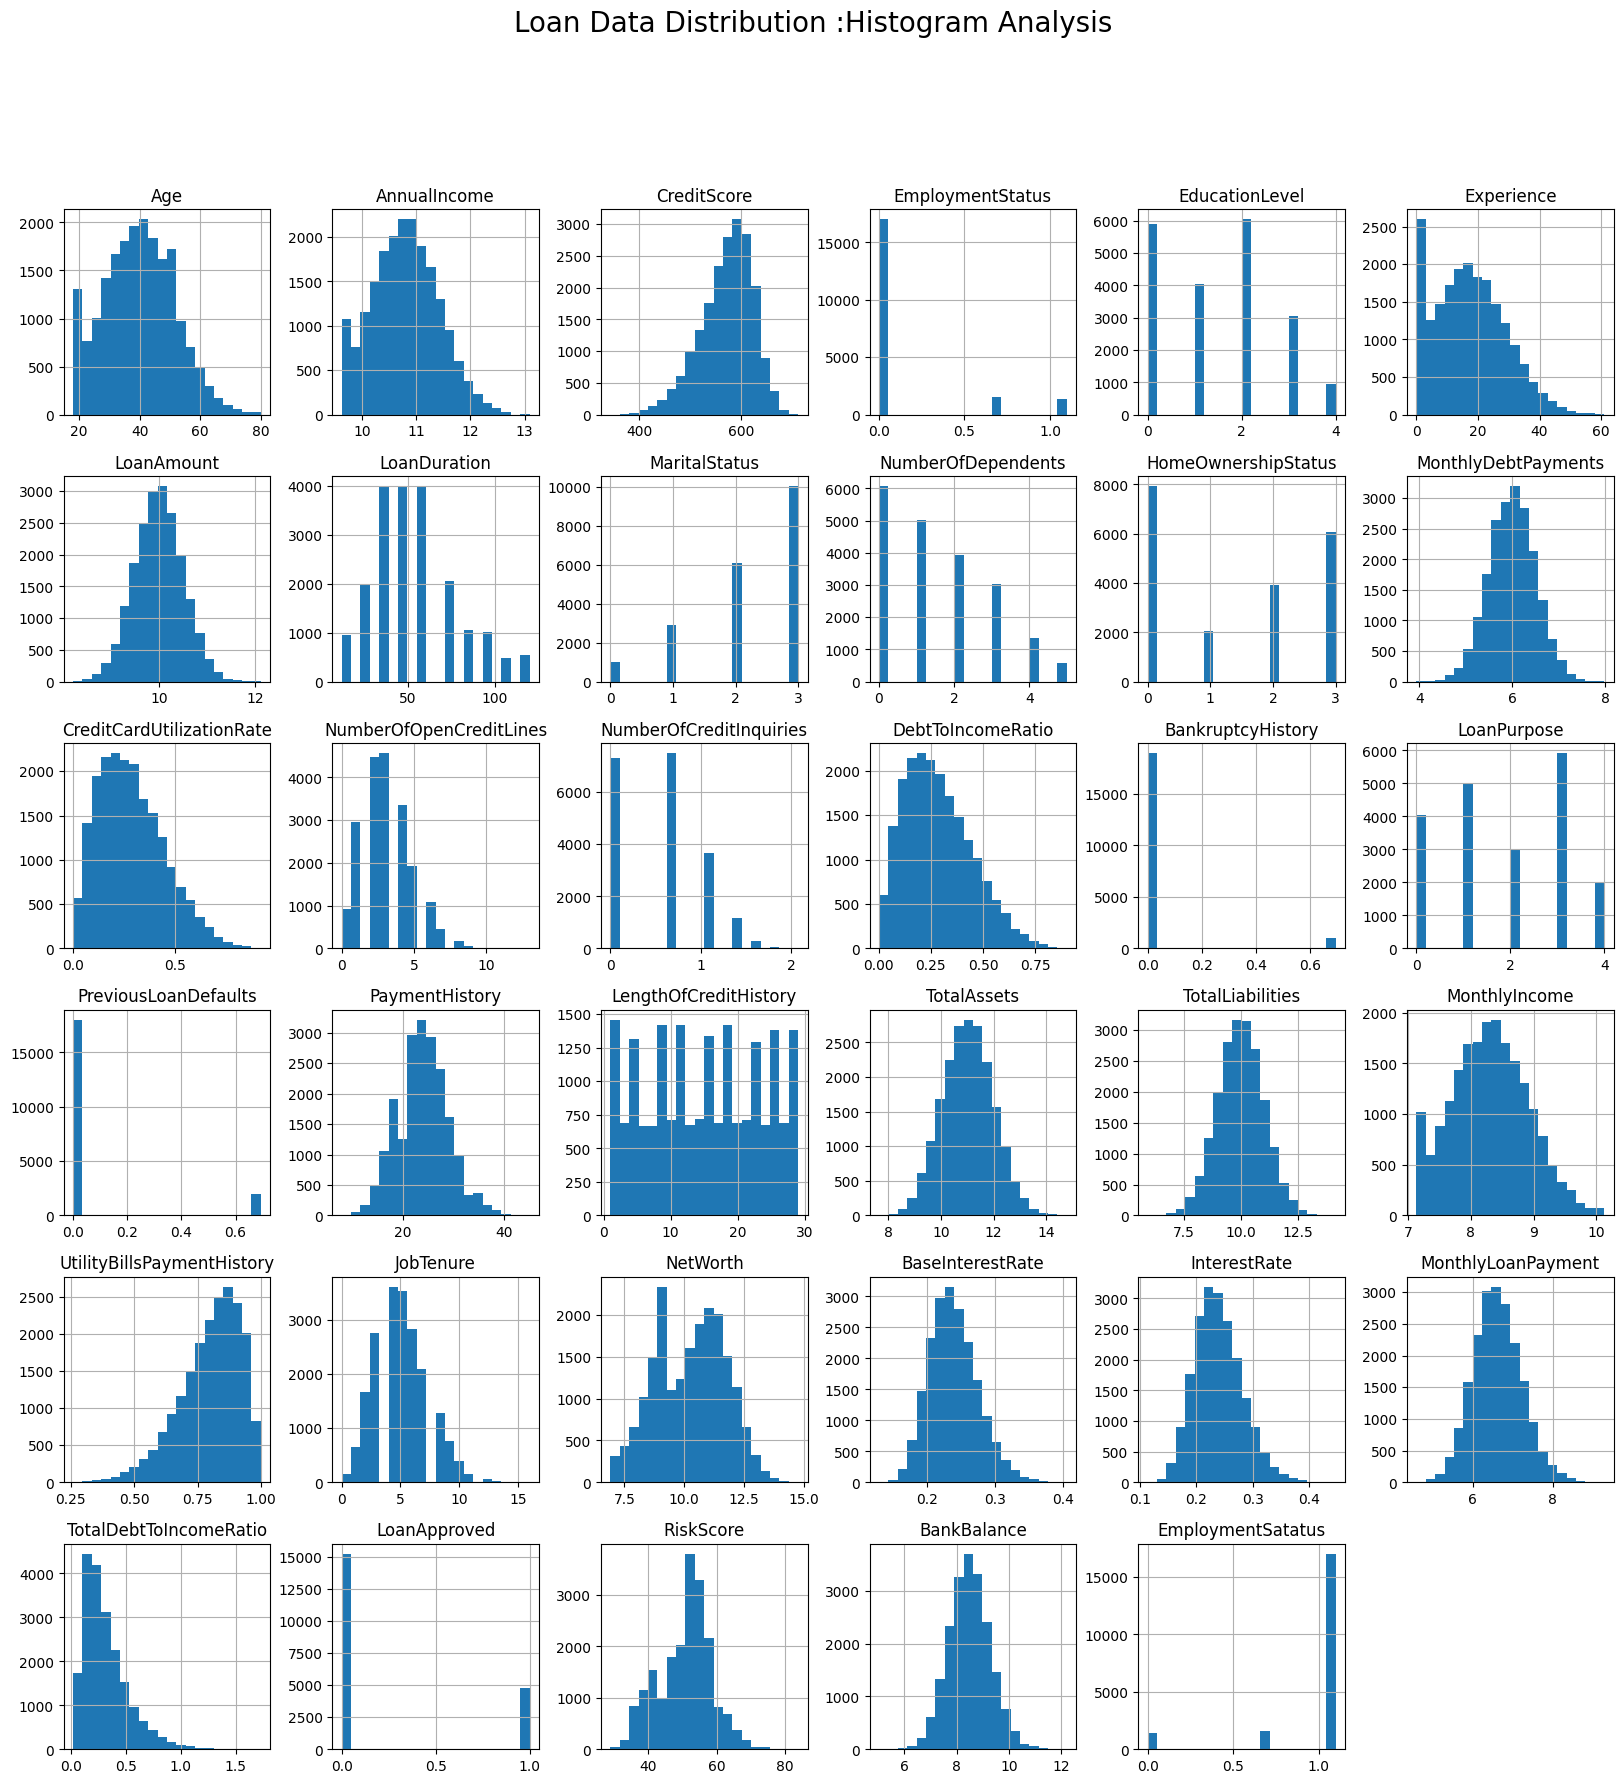

In [38]:
rd.hist(bins=20, figsize=(20,20))
plt.suptitle("Loan Data Distribution :Histogram Analysis",fontsize=20)
plt.show()

# (3.2) REMOVING UNWANTED FEATURES

(3.2.1) Based on Correlation

<Axes: >

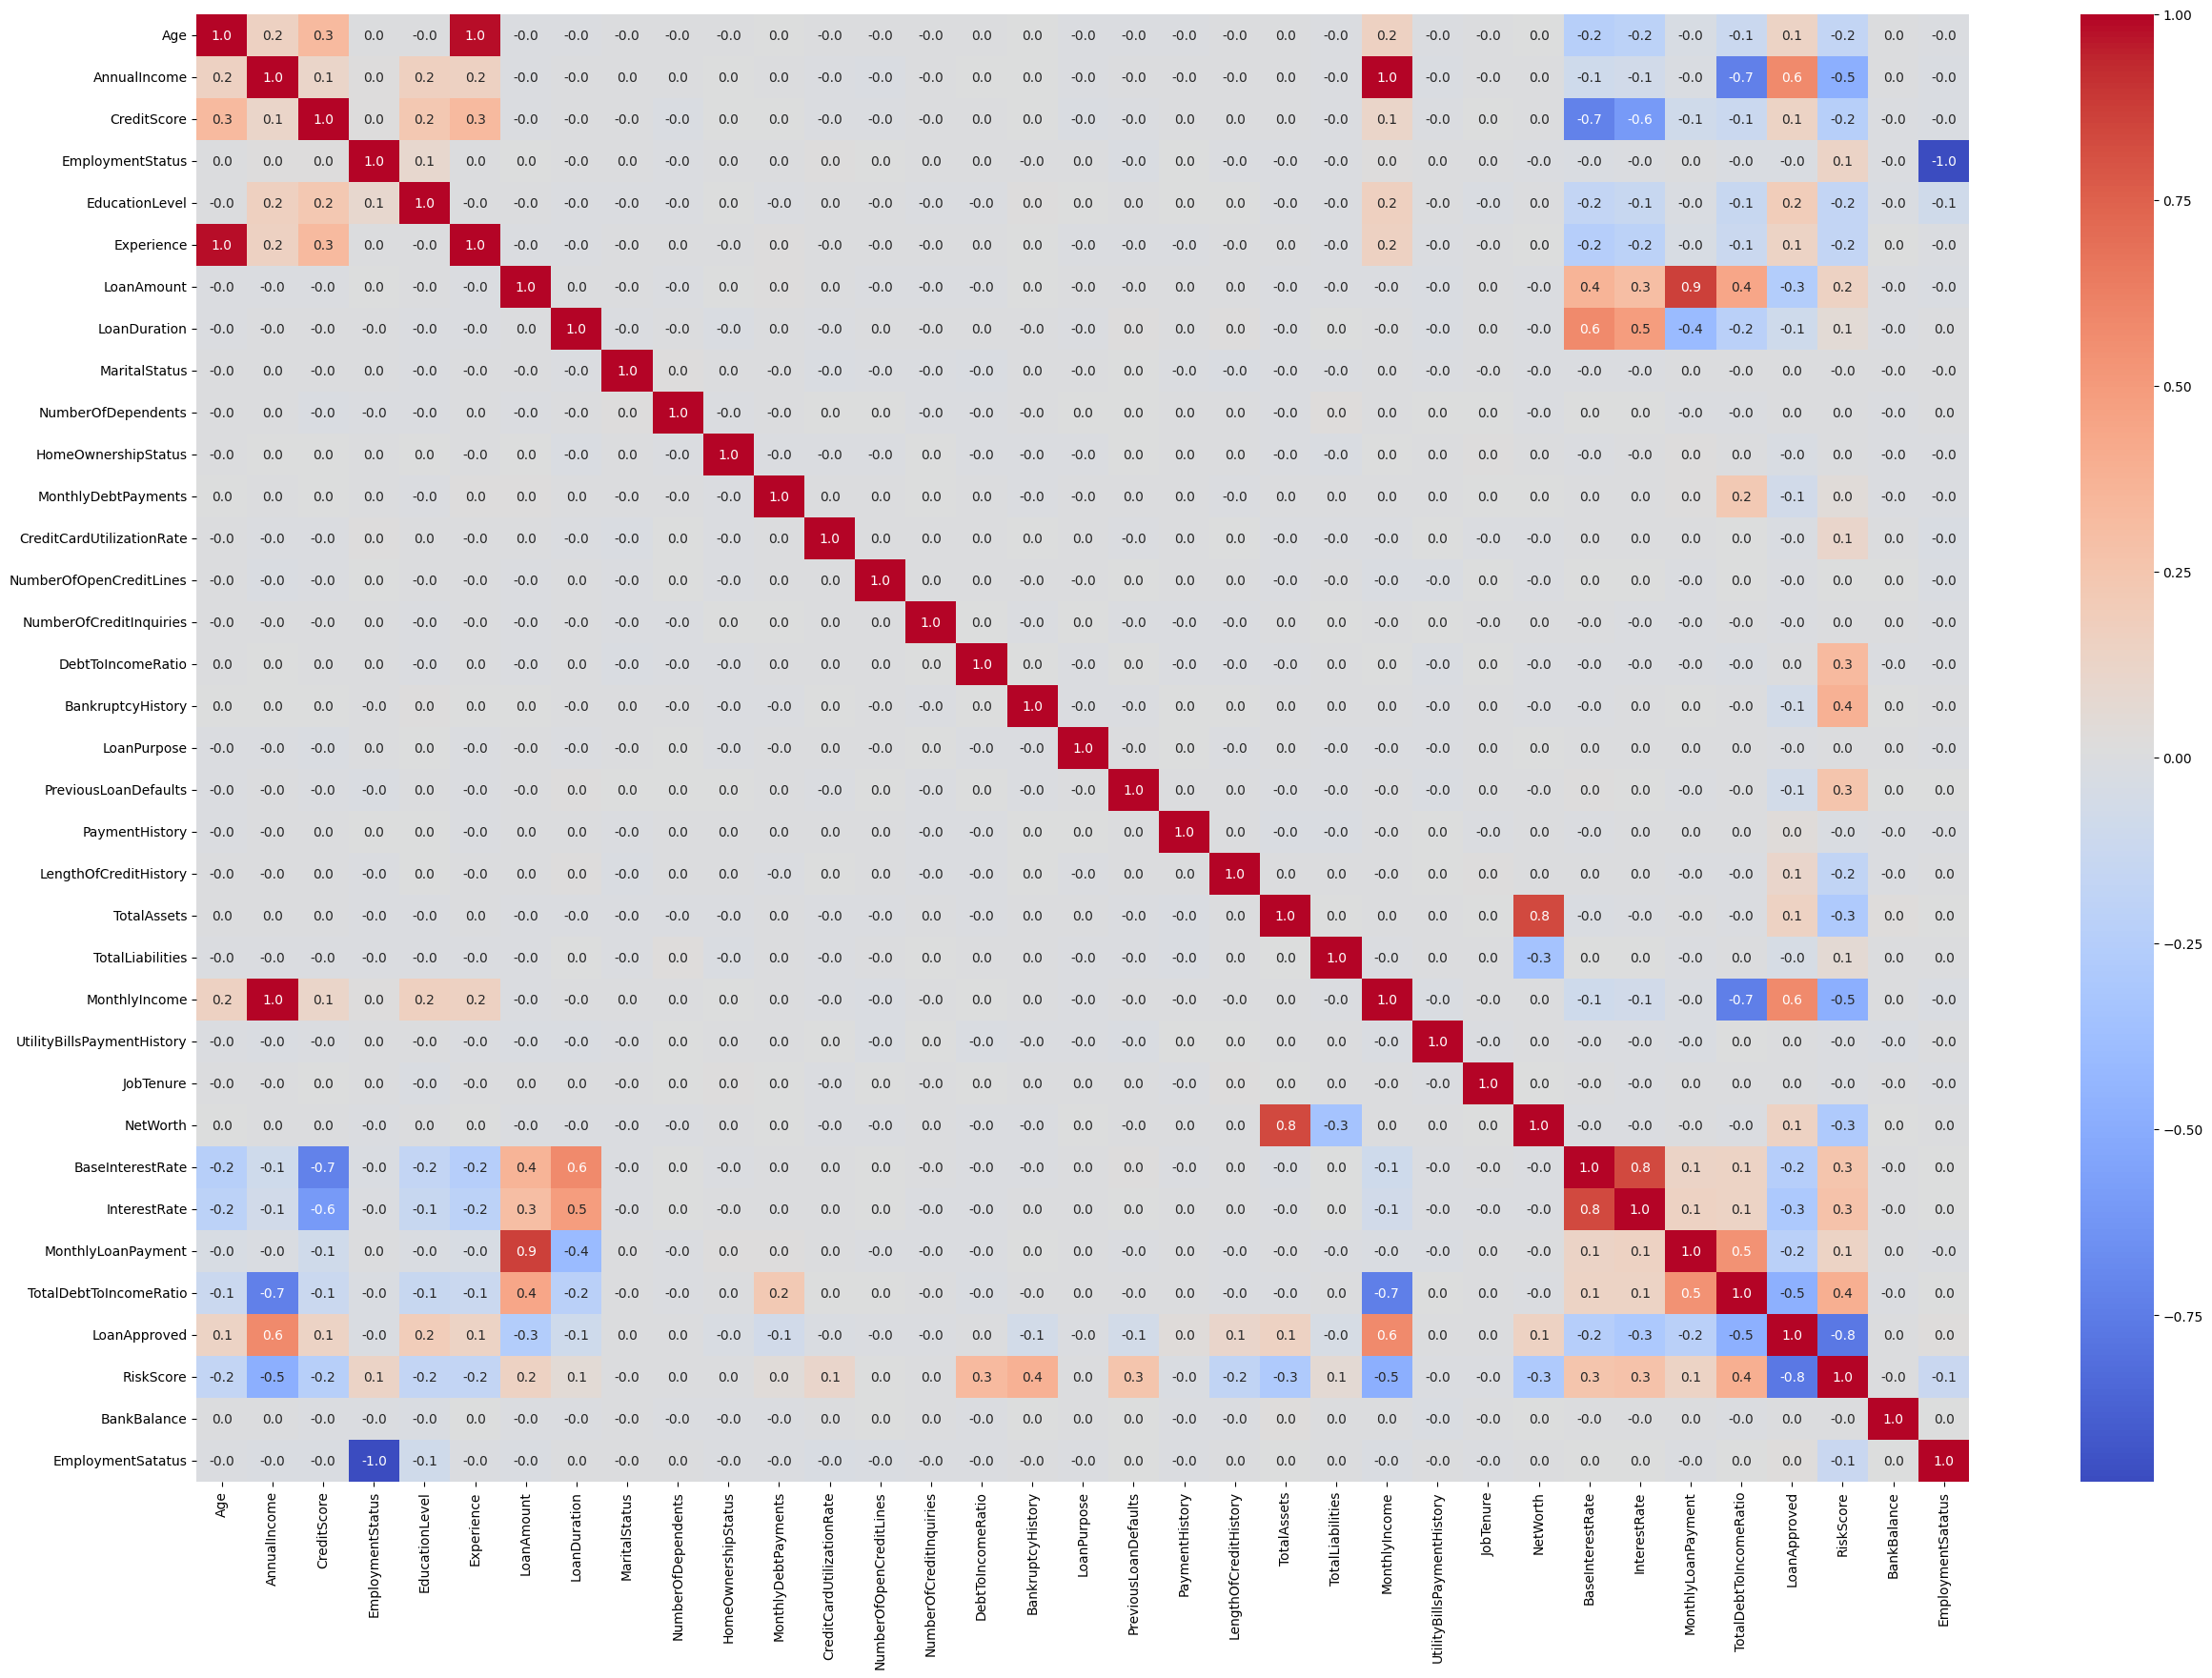

In [39]:
plt.figure(figsize=(30,20))
rd.corr(numeric_only=True)
sns.heatmap(rd.corr(numeric_only=True),annot=True, cmap='coolwarm',fmt='0.01f')

In [40]:
rd.corr()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,BankBalance,EmploymentSatatus
Age,1.000000,0.156663,0.323243,0.003527,-0.001970,0.982980,-0.005580,-0.006992,-0.001151,-0.000287,...,-0.000773,0.006656,-0.238995,-0.202702,-0.027758,-0.123050,0.141029,-0.164304,0.005178,-0.002852
AnnualIncome,0.156663,1.000000,0.117193,0.018121,0.159894,0.158160,-0.005187,-0.001902,0.002177,0.001024,...,-0.001671,0.003253,-0.087288,-0.075183,-0.010119,-0.733132,0.577045,-0.484203,0.005291,-0.015064
CreditScore,0.323243,0.117193,1.000000,0.019501,0.230306,0.327664,-0.009231,-0.000762,-0.001845,-0.014453,...,0.008069,0.001043,-0.722619,-0.598844,-0.080825,-0.125033,0.142000,-0.240198,-0.005228,-0.016420
EmploymentStatus,0.003527,0.018121,0.019501,1.000000,0.091883,0.002957,0.008573,-0.001561,0.001951,-0.003071,...,0.003350,-0.004265,-0.011463,-0.009792,0.005517,-0.010845,-0.016049,0.133225,-0.005111,-0.973517
EducationLevel,-0.001970,0.159894,0.230306,0.091883,1.000000,-0.001128,-0.000765,-0.002447,-0.006125,-0.004994,...,-0.016901,0.001854,-0.167695,-0.139859,-0.015631,-0.133575,0.194434,-0.164848,-0.015996,-0.081362
Experience,0.982980,0.158160,0.327664,0.002957,-0.001128,1.000000,-0.005393,-0.007924,-0.000300,0.000136,...,-0.000762,0.006633,-0.242871,-0.206252,-0.027939,-0.123991,0.140755,-0.166496,0.006080,-0.002586
LoanAmount,-0.005580,-0.005187,-0.009231,0.008573,-0.000765,-0.005393,1.000000,0.000126,-0.002083,-0.009104,...,0.001044,-0.002563,0.360816,0.302460,0.862680,0.444596,-0.259575,0.151177,-0.002476,-0.010498
LoanDuration,-0.006992,-0.001902,-0.000762,-0.001561,-0.002447,-0.007924,0.000126,1.000000,-0.007523,-0.001301,...,0.003635,-0.005524,0.579215,0.487994,-0.404565,-0.218800,-0.094558,0.054550,-0.006214,0.000028
MaritalStatus,-0.001151,0.002177,-0.001845,0.001951,-0.006125,-0.000300,-0.002083,-0.007523,1.000000,0.020110,...,-0.001612,-0.003268,-0.005618,-0.009832,0.000805,-0.001075,0.000999,-0.001053,-0.002039,-0.000650
NumberOfDependents,-0.000287,0.001024,-0.014453,-0.003071,-0.004994,0.000136,-0.009104,-0.001301,0.020110,1.000000,...,0.010910,-0.009468,0.006977,0.006749,-0.005865,-0.002420,0.001717,0.001686,-0.002764,0.003093


In [41]:
rd[['TotalDebtToIncomeRatio','MonthlyIncome']].corr()

,TotalDebtToIncomeRatio,MonthlyIncome
TotalDebtToIncomeRatio,1.000000,-0.736617
MonthlyIncome,-0.736617,1.000000


In [42]:
rd.drop('TotalDebtToIncomeRatio',axis=1,inplace=True)

In [43]:
corr_matrix=rd.corr()

#set the correlation threshold
threshold=0.5

# Find pairs of features with high correlation 
highly_correlated_pairs=[]
for i in range (len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i,j])>threshold:   #check if the absolute correlation exceeds the threshold
            highly_correlated_pairs.append((corr_matrix.columns[i],corr_matrix.columns[j]))


#Print all pairs of highly correlated features
print(highly_correlated_pairs)

[('Experience', 'Age'), ('MonthlyIncome', 'AnnualIncome'), ('NetWorth', 'TotalAssets'), ('BaseInterestRate', 'CreditScore'), ('BaseInterestRate', 'LoanDuration'), ('InterestRate', 'CreditScore'), ('InterestRate', 'BaseInterestRate'), ('MonthlyLoanPayment', 'LoanAmount'), ('LoanApproved', 'AnnualIncome'), ('LoanApproved', 'MonthlyIncome'), ('RiskScore', 'LoanApproved'), ('EmploymentSatatus', 'EmploymentStatus')]


In [44]:
rd.drop(['Experience','AnnualIncome','TotalAssets','BaseInterestRate','MonthlyLoanPayment'],axis=1,inplace=True)

In [45]:
# OR ^ correlation nokkumbo valyadatasetil kore correlation undenkil thayathr code use cheyyuka

In [46]:
#step1: Calculate the correlation of each feature with the target
corr_with_target=rd.corr()['LoanApproved'].sort_values(ascending=False)

#step2: set the trushold for low correlation (-0.05 to 0.05)
low_corr_feature=corr_with_target[(corr_with_target>-0.05)&
                                  (corr_with_target<0.05)]

#step#: Print the list of features with low correlation
print("Features with correlation between -0.05 and 0.05:")
print(low_corr_feature)

Features with correlation between -0.05 and 0.05:
PaymentHistory                0.030804
EmploymentSatatus             0.024961
JobTenure                     0.004997
BankBalance                   0.004973
UtilityBillsPaymentHistory    0.003303
NumberOfDependents            0.001717
MaritalStatus                 0.000999
DebtToIncomeRatio             0.000034
NumberOfOpenCreditLines      -0.004769
NumberOfCreditInquiries      -0.006837
LoanPurpose                  -0.007062
CreditCardUtilizationRate    -0.010466
EmploymentStatus             -0.016049
HomeOwnershipStatus          -0.018135
TotalLiabilities             -0.033293
Name: LoanApproved, dtype: float64


In [47]:
#BELOW FEATURES are very less Correlated with the target variable:
rd.drop(['JobTenure','UtilityBillsPaymentHistory','NumberOfDependents','DebtToIncomeRatio','NumberOfOpenCreditLines','NumberOfCreditInquiries','MaritalStatus','LoanPurpose'],axis=1,inplace=True)

In [48]:
#step1: Calculate the correlation of each feature with the target
corr_with_target=rd.corr()['RiskScore'].sort_values(ascending=False)

#step2: set the trushold for low correlation (-0.05 to 0.05)
low_corr_feature=corr_with_target[(corr_with_target>-0.05)&
                                  (corr_with_target<0.05)]

#step#: Print the list of features with low correlation
print("Features with correlation between -0.05 and 0.05:")
print(low_corr_feature)

Features with correlation between -0.05 and 0.05:
MonthlyDebtPayments    0.037533
HomeOwnershipStatus    0.004454
BankBalance           -0.001408
PaymentHistory        -0.016992
Name: RiskScore, dtype: float64


In [49]:
rd.drop(['MonthlyDebtPayments','HomeOwnershipStatus','PaymentHistory','BankBalance'],axis=1,inplace=True)

In [50]:
rd.drop(['LoanDuration','EducationLevel','Age'],axis=1,inplace=True)

In [51]:
rd.columns

Index(['CreditScore', 'EmploymentStatus', 'LoanAmount',
       'CreditCardUtilizationRate', 'BankruptcyHistory',
       'PreviousLoanDefaults', 'LengthOfCreditHistory', 'TotalLiabilities',
       'MonthlyIncome', 'NetWorth', 'InterestRate', 'LoanApproved',
       'RiskScore', 'EmploymentSatatus'],
      dtype='object')

(3.2.2) PCA

PCA reduces the number of features(dimensions) in a dataset.
* Principal Components: These are the new features created by PCA .Each principal component it is linear combination of the original features and they are ranked based on the amount of variance  they explain in the data.

In [52]:
from sklearn.decomposition import PCA
#Apply PCA
pca=PCA(n_components=5) # you can change the number of components to retain
loan_pca=pca.fit_transform(rd)

#Create a Dataframe with the PCA results
loan_pca_rd=pd.DataFrame(loan_pca,columns=[f'PC{i+1}' for i in range (loan_pca.shape[1])])

#Now loan_pca_final_df contains the original data along with PCA components
loan_pca_rd.head()

,PC1,PC2,PC3,PC4,PC5
0,45.415153,-5.117699,-3.170686,1.364644,0.451686
1,56.295067,-6.875699,-0.187578,0.847053,-0.549699
2,-1.650952,5.432642,4.698939,-2.104756,1.017323
3,-26.719528,-5.348161,-0.665711,1.746999,-0.832384
4,22.939593,17.473385,-6.044609,1.257522,0.366997


# (3.3) SCALING

In [53]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [54]:
# create a copy of the original data for comparison
rd_scaled=rd.copy()

#select numeric coumns excluding 'LoanApproved'
numeric_cols=rd.drop(columns=['LoanApproved']).select_dtypes(include=['number']).columns

#initialize the standerdscaler
scaler=StandardScaler()

#apply the scaler only to the numeric columns
rd_scaled[numeric_cols]=scaler.fit_transform(rd[numeric_cols])
rd_scaled.head()

,CreditScore,EmploymentStatus,LoanAmount,CreditCardUtilizationRate,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,TotalLiabilities,MonthlyIncome,NetWorth,InterestRate,LoanApproved,RiskScore,EmploymentSatatus
0,0.890021,-0.404834,-1.014008,0.425792,-0.235154,-0.333426,-0.711630,-0.136881,-0.324366,1.020941,-0.272968,0,-0.227149,0.371144
1,1.105724,-0.404834,0.343015,-1.242602,-0.235154,-0.333426,-0.711630,-0.828648,-0.334247,0.287206,-0.901165,0,0.158551,0.371144
2,-0.031618,-0.404834,-0.432362,-0.932273,-0.235154,-0.333426,0.841287,1.765237,-0.292687,-1.172566,-0.629370,0,0.158551,0.371144
3,-0.521852,-0.404834,1.087972,-0.117617,-0.235154,-0.333426,-0.592175,-1.408173,0.577602,0.853401,1.464331,0,0.415684,0.371144
4,0.439006,-0.404834,-1.727221,0.213746,-0.235154,-0.333426,1.438563,-0.240858,1.239575,1.420252,-1.495584,1,-1.898515,0.371144


MIN -MAX Scaling:
$$x'=\frac{x-min(x)}{max(x)-min(x)}$$
Standard Scaling:
$$z=\frac{x-\mu}{\sigma}$$

# (3.4) Handling Outliers

BOXPLOTS

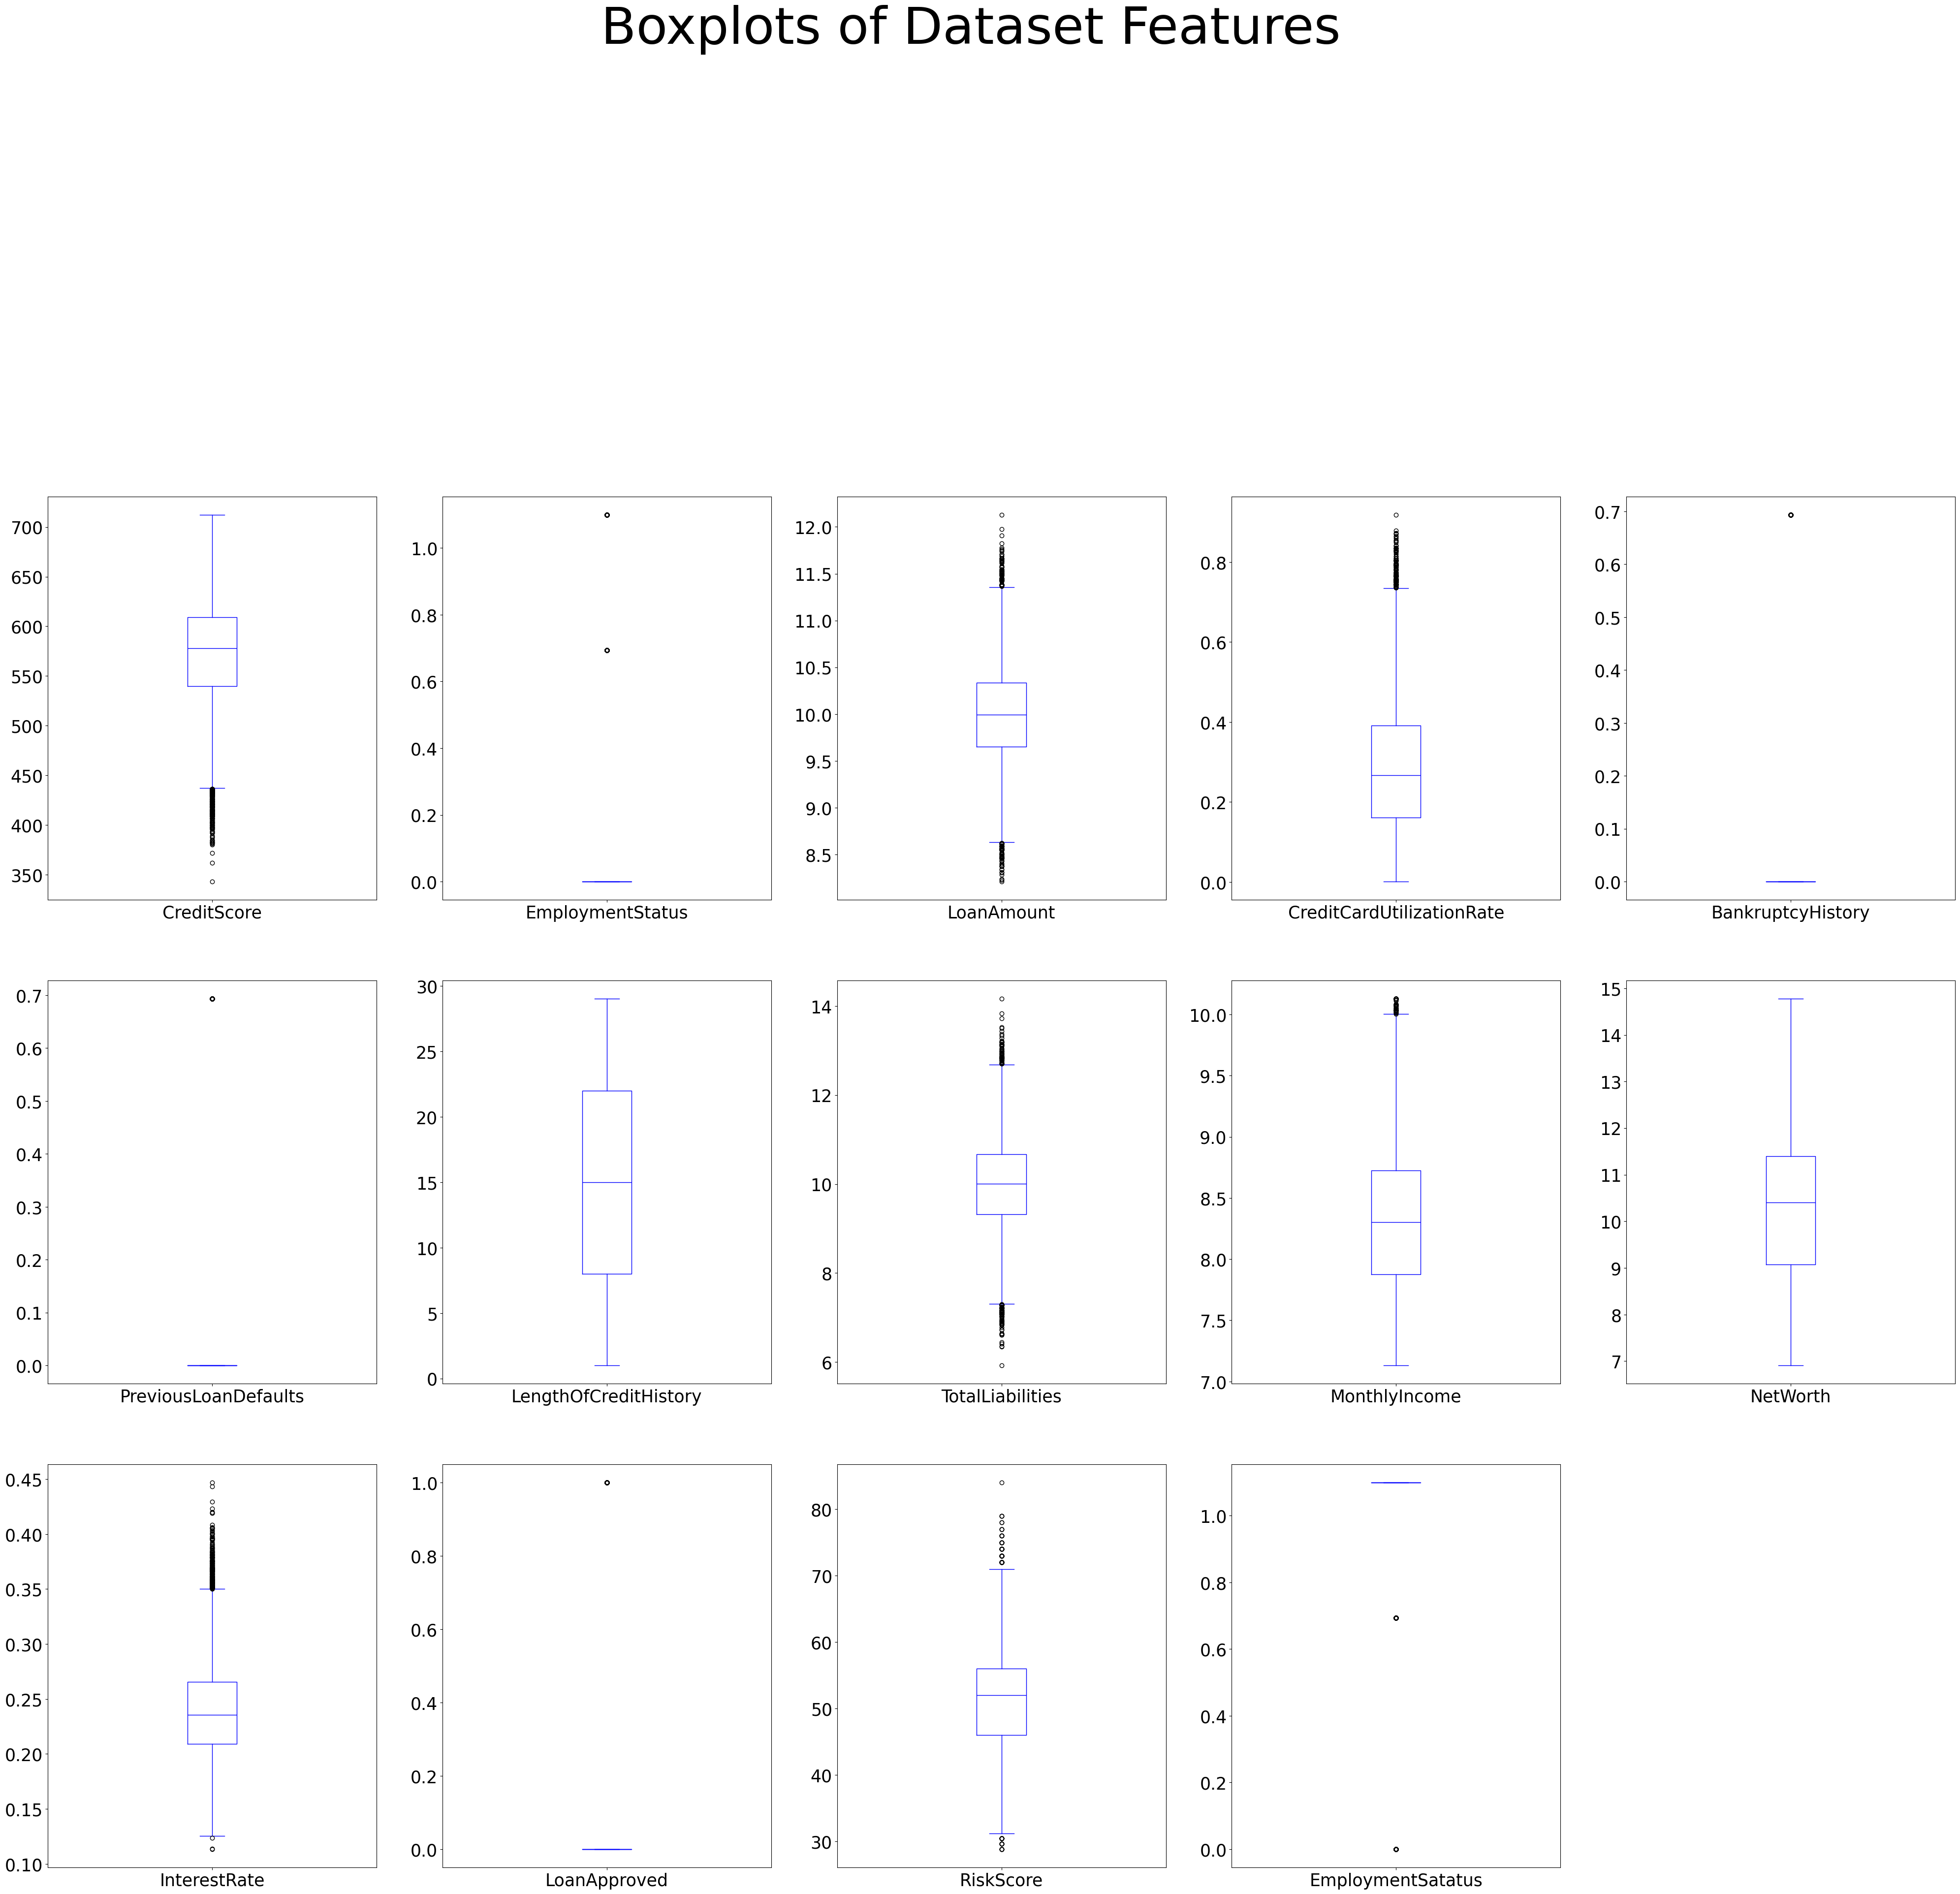

In [55]:
rd.plot(kind='box',subplots=True,layout=(8,5),figsize=(50,100),color='blue',fontsize=25)
plt.suptitle("Boxplots of Dataset Features",fontsize=75)
plt.show()


In [56]:
# create a copy the original data for comparison
rd_copy=rd.copy()

def remove_outliers_iqr(df,exclude_columns):
    #Loop thruogh numeric columns
    for column in df.select_dtypes(include=['number']):
        if column in exclude_columns:
            continue  #skip exclude columns

        Q1=df[column].quantile(0.25)
        Q3=df[column].quantile(0.75)
        IQR=Q3-Q1

        #Define outlier bonds
        lower_bond=Q1-1.5*IQR
        upper_bond=Q3+1.5*IQR

        #Filter out the outliers
        df=df[(df[column]>=lower_bond)& (df[column]<=upper_bond)]
    return df

#Define the columns to exclude 
exclude_columns=['LoanApproved','RiskScore','EmploymentStatus']

#remove outliers
rd=remove_outliers_iqr(rd,exclude_columns)

#print shapes of data before and after removing outliers
print("shape of data before removing outliers :",rd_copy.shape)
print("shape of data after removing outliers :",rd.shape)
print("Number of outlier removed:",rd_copy.shape[0]-rd.shape[0])

shape of data before removing outliers : (20000, 14)
shape of data after removing outliers : (13860, 14)
Number of outlier removed: 6140


## (step4) MODEL TRAINING AND EVALUATION

In [57]:
# MODELS
# for regression algorithms
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor,RandomForestRegressor,BaggingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

#for classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn import model_selection

#from sklearn.utils import class_weight
#from sklearn.model_selection import 

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_classification
from sklearn import svm
from sklearn import tree

# (4.1) Regression Modeling

**` Risk Score Regression `**: To predict a continueus risk score associated with each individuals likelihood of loan default or financial instability

In [58]:
models={"Linear_Regression":LinearRegression(),
        "RandomForest_Regressor":RandomForestRegressor(),
        "GradientBoosting_Regressore":GradientBoostingRegressor(),
        "DecisionTree_Regressor":DecisionTreeRegressor(),
        "svm":SVR(),

        #"MLP_Regressor":MLPRegressor(max_iter=500),
        "AdaBoostRegressor":AdaBoostRegressor(),
        "ExtraTreesRegressor":ExtraTreesRegressor(),
        "BaggingRegressor":BaggingRegressor(),
        "LGBMRegressor":LGBMRegressor(),

        #"CatBoostRegressor":CatBoostRegressor(),
        "XGBRegressor":XGBRegressor()}

In [59]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

In [60]:
x1=rd.drop(["RiskScore","LoanApproved"],axis=1)
y1=rd[["RiskScore"]]

In [61]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,random_state=42,test_size=0.2)

print('shape of training feature:',x1_train.shape)
print('shape of testing feature :', x1_test.shape)
print('shape of training target:',y1_train.shape)
print('shape of testing target:',y1_test.shape)

shape of training feature: (11088, 12)
shape of testing feature : (2772, 12)
shape of training target: (11088, 1)
shape of testing target: (2772, 1)


In [62]:
#Dictionary to store results 
results={'Model':[],'MSE':[],'MAE':[],'R2':[]}

#Loop through the models ,train them and calculate the matrics
for model_name,model in models.items():
    #TRAIN THE MODEL
    model.fit(x1_train,y1_train)

    #make predictions
    y1_pred=model.predict(x1_test)

    #calculate metrics
    mse=mean_squared_error(y1_test,y1_pred)
    mae=mean_absolute_error(y1_test,y1_pred)
    r2=r2_score(y1_test,y1_pred)

    #store results in the dictionary
    results['Model'].append(model_name)
    results['MSE'].append(mse)
    results['MAE'].append(mae)
    results['R2'].append(r2)

#convert results to a DataFrame
results_df=pd.DataFrame(results) 

#Sidplay the results
results_df

c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validat

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1796
[LightGBM] [Info] Number of data points in the train set: 11088, number of used features: 8
[LightGBM] [Info] Start training from score 48.885877


,Model,MSE,MAE,R2
0,Linear_Regression,19.504458,3.561857,0.581294
1,RandomForest_Regressor,13.400641,2.885150,0.712326
2,GradientBoosting_Regressore,13.082908,2.869557,0.719146
3,DecisionTree_Regressor,27.300043,3.907431,0.413944
4,svm,42.098469,5.002368,0.096263
5,AdaBoostRegressor,21.371284,3.720689,0.541218
6,ExtraTreesRegressor,13.356192,2.882442,0.713280
7,BaggingRegressor,14.815528,3.012092,0.681952
8,LGBMRegressor,12.498865,2.796122,0.731684
9,XGBRegressor,13.961701,2.942801,0.700281


In [63]:
x1s=rd_scaled.drop(['RiskScore','LoanApproved'],axis=1)
y1s=rd_scaled[['RiskScore']]

x1s_train,x1s_test,y1s_train,y1s_test=train_test_split(x1s,y1s,random_state=42,test_size=0.2)

#Dictionary to store results 
results={'Model':[],'MSE':[],'MAE':[],'R2':[]}

#Loop through the models ,train them and calculate the matrics
for model_name,model in models.items():
    #TRAIN THE MODEL
    model.fit(x1s_train,y1s_train)

    #make predictions
    y1s_pred=model.predict(x1s_test)

    #calculate metrics
    mse1=mean_squared_error(y1s_test,y1s_pred)
    mae1=mean_absolute_error(y1s_test,y1s_pred)
    r21=r2_score(y1s_test,y1s_pred)

    #store results in the dictionary
    results['Model'].append(model_name)
    results['MSE'].append(mse1)
    results['MAE'].append(mae1)
    results['R2'].append(r21)

#convert results to a DataFrame
results_df1=pd.DataFrame(results) 

#sort by accuracy
results_df1=results_df1.sort_values(by='R2',ascending=False)

#Display the sorted dataframe with background gradient
results_df1.style.background_gradient('Blues')


c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validat

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1798
[LightGBM] [Info] Number of data points in the train set: 16000, number of used features: 12
[LightGBM] [Info] Start training from score 0.009876


,Model,MSE,MAE,R2
8,LGBMRegressor,0.222196,0.374619,0.783492
6,ExtraTreesRegressor,0.236559,0.380741,0.769496
2,GradientBoosting_Regressore,0.236644,0.384859,0.769413
1,RandomForest_Regressor,0.243310,0.383562,0.762917
9,XGBRegressor,0.245344,0.391055,0.760936
4,svm,0.247108,0.392986,0.759216
7,BaggingRegressor,0.267096,0.398825,0.739740
0,Linear_Regression,0.351096,0.479736,0.657890
5,AdaBoostRegressor,0.422772,0.526381,0.588049
3,DecisionTree_Regressor,0.477275,0.520116,0.534941


# (4.2) Classification Modeling :

**Binary Loan Approval Classification** : To determine the binary outcome of loan approval,indicating whether an applicant is likely to be approved or denied for a loan

In [64]:
#convert "LoanApproved" from float to int

rd['LoanApproved']=rd['LoanApproved'].astype(int)

x=rd.drop(['LoanApproved','RiskScore'],axis=1)
y=rd[['LoanApproved']]

In [65]:
rd[['LoanApproved']].value_counts()

LoanApproved
0               10261
1                3599
Name: count, dtype: int64

In [66]:
#for Evaluation

from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

In [67]:
#for classification algorithm

from sklearn.linear_model import LogisticRegression

In [68]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

print('shape of training feature:',x_train.shape)
print('shape of testing feature :', x_test.shape)
print('shape of training target:',y_train.shape)
print('shape of testing target:',y_test.shape)

shape of training feature: (11088, 12)
shape of testing feature : (2772, 12)
shape of training target: (11088, 1)
shape of testing target: (2772, 1)


In [69]:
model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

#Accuracy
arcy=accuracy_score(y_test,y_pred)
print("Accuracy:",arcy)

#confusion matrics
print("\nconfusion matrics:\n",confusion_matrix(y_test,y_pred))

#Detailed classification report
print("\nClassification report:\n",classification_report(y_test,y_pred))

#

Accuracy: 0.902958152958153

confusion matrics:
 [[1942  116]
 [ 153  561]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      2058
           1       0.83      0.79      0.81       714

    accuracy                           0.90      2772
   macro avg       0.88      0.86      0.87      2772
weighted avg       0.90      0.90      0.90      2772



c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [70]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: xgboost in c:\users\pc\appdata\local\programs\python\python312\lib\site-packages (3.1.1)




[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
# MODELS
# for regression algorithms
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor,RandomForestRegressor,BaggingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

#for classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn import model_selection

#from sklearn.utils import class_weight
#from sklearn.model_selection import 

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_classification
from sklearn import svm
from sklearn import tree

In [73]:
clas_models={'lr':LogisticRegression(max_iter=500),
             'rfc':RandomForestClassifier(),
             'dtc':DecisionTreeClassifier(),
             'knn':KNeighborsClassifier(n_neighbors=11),
             'svm':SVC(kernel='linear'),
             'gbc':GradientBoostingClassifier(random_state=0,learning_rate=0.45),
             'etc':ExtraTreesClassifier(),
             'nb':GaussianNB()}

In [74]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

#Dictionary to store result
results={'Model':[],'Accuracy':[],'Precision':[],'Recall':[],'F1-Score':[]}

#Evaluate each model 
for model_name ,model in clas_models.items():
    #train the model 
    model.fit(x_train,y_train)
    model_pred=model.predict(x_test)

    #calculate metrics
    accuracy=accuracy_score(y_test,model_pred)
    precision=precision_score(y_test,model_pred)
    recall=recall_score(y_test,model_pred)
    f1=f1_score(y_test,model_pred)

    #store results in the dictionary 
    results['Model'].append(model)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1-Score'].append(f1)

#convert results to a Dataframe 
results_df=pd.DataFrame(results)

#Display the results in a table
results_df

c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was ex

,Model,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression(max_iter=500),0.917027,0.866667,0.801120,0.832606
1,"(DecisionTreeClassifier(max_features='sqrt', r...",0.922439,0.882083,0.806723,0.842721
2,DecisionTreeClassifier(),0.888528,0.778542,0.792717,0.785566
3,KNeighborsClassifier(n_neighbors=11),0.760823,0.618605,0.186275,0.286329
4,SVC(kernel='linear'),0.923882,0.863965,0.836134,0.849822
5,([DecisionTreeRegressor(criterion='friedman_ms...,0.930014,0.874640,0.850140,0.862216
6,"(ExtraTreeClassifier(random_state=1444505227),...",0.917388,0.890499,0.774510,0.828464
7,GaussianNB(),0.905123,0.856240,0.759104,0.804751


(4.2.1) Classification On scaled Data

In [75]:
x2s=rd_scaled.drop('LoanApproved',axis=1)
y2s=rd_scaled[['LoanApproved']]

x2s_train,x2s_test,y2s_train,y2s_test=train_test_split(x2s,y2s,random_state=42,test_size=0.2)

#Dictionary to store result
results={'Model':[],'Accuracy':[],'Precision':[],'Recall':[],'F1-Score':[]}

#Evaluate each model 
for model_name ,model in clas_models.items():
    #train the model 
    model.fit(x2s_train,y2s_train)
    model_pred2s=model.predict(x2s_test)

    #calculate metrics
    accuracy2=accuracy_score(y2s_test,model_pred2s)
    precision2=precision_score(y2s_test,model_pred2s)
    recall2=recall_score(y2s_test,model_pred2s)
    f12=f1_score(y2s_test,model_pred2s)

    #store results in the dictionary 
    results['Model'].append(model)
    results['Accuracy'].append(accuracy2)
    results['Precision'].append(precision2)
    results['Recall'].append(recall2)
    results['F1-Score'].append(f12)

#convert results to a Dataframe 
results_df2=pd.DataFrame(results)

#sort by accuracy
results_df2=results_df2.sort_values(by='Accuracy',ascending=False)

#Display the sorted dataframe with background gradient
results_df2.style.background_gradient('Blues')

#Display the results in a table
# results_df2



c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\Pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWa

,Model,Accuracy,Precision,Recall,F1-Score
5,"GradientBoostingClassifier(learning_rate=0.45, random_state=0)",0.999000,0.998033,0.998033,0.998033
4,SVC(kernel='linear'),0.996750,0.996047,0.991150,0.993593
0,LogisticRegression(max_iter=500),0.996500,0.995064,0.991150,0.993103
6,ExtraTreesClassifier(),0.995000,0.997009,0.983284,0.990099
1,RandomForestClassifier(),0.993500,0.993035,0.981318,0.987141
2,DecisionTreeClassifier(),0.990500,0.986097,0.976401,0.981225
3,KNeighborsClassifier(n_neighbors=11),0.989250,0.994919,0.962635,0.978511
7,GaussianNB(),0.954250,0.904070,0.917404,0.910688


## **FINAL REPORT**

> Based on the analysis of the loan approval dataset for predicting the `RiskScore`, the `LGBMRegressor` model demonstrated the best perfomance amoung the tested models

> Based on the evaluation of the classification models for predicting `LoanApproval`, the `GradientBoostingClassifier` with a learning rate of 0.45 and random state set to 0 emerged as the best performing model . it acheived the highest accuracy and consistently strong results across precision, recall, and F1-score ,making it the most reliable model for classifying whether a loan is approved or not in the loan dataset.

# **PICKLE FILE**

In [76]:
import pickle 

r_model=LinearRegression()
r_model.fit(x1s_train,y1s_train.values.ravel())
with open ("regression_model.pkl",'wb') as file:
    pickle.dump(r_model,file)



 #save the classification model
c_model=GradientBoostingClassifier(random_state=0,learning_rate=0.45)
c_model.fit(x2s_train,y2s_train.values.ravel())
with open ("classification_model.pkl",'wb') as file:
    pickle.dump(c_model,file)
